#### 1 - Leitura da BD e carregar as bibliotecas iniciais

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
data_nsa = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/falta_consultas-may-2016.csv")
data_nsa.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
data_nsa.shape

(110527, 14)

###2 - Veirificar a quantidade de valores faltantes e as categorias das variáveis.

In [4]:
data_nsa.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [5]:
data_nsa.dtypes

,0
PatientId,float64
AppointmentID,int64
Gender,object
ScheduledDay,object
AppointmentDay,object
Age,int64
Neighbourhood,object
Scholarship,int64
Hipertension,int64
Diabetes,int64


## 3 - EDA - Descrição das Variáveis Numéricas

Vamos começar obtendo as estatísticas descritivas para as colunas numéricas do DataFrame `data_nsa`.

In [6]:
display(data_nsa.describe())

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


#### Pela análise anterior percebemos uma pessoa com idade negativa, como estava documentado que esse paciente é um "problema" da bd, vamos optar por removê-lo.

In [7]:
data_nsa = data_nsa[data_nsa['Age'] >= 0]
display(data_nsa.describe())

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105260e+05,1.105260e+05,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000
mean,1.474934e+14,5.675304e+06,37.089219,0.098266,0.197248,0.071865,0.030400,0.022248,0.321029
std,2.560943e+14,7.129544e+04,23.110026,0.297676,0.397923,0.258266,0.171686,0.161543,0.466874
min,3.921784e+04,5.030230e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172536e+12,5.640285e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680572e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.438963e+13,5.725523e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [8]:
data_nsa.shape

(110526, 14)

#### 3.1 - Para facilitar o etndendimento dos nomes das variáveis, vamos alterar para nomes usuais.

In [9]:
data_nsa.rename(columns={
    'Age': 'Idade',
    'Gender': 'Genero',
    'Scholarship': 'Bolsa_Familia',
    'Hipertension': 'Hipertensao',
    'Diabetes': 'Diabetes',
    'Alcoholism': 'Alcoolismo',
    'Handcap': 'Deficiencia',
    'SMS_received': 'Recebeu_SMS',
    'PatientId': 'ID_Paciente',
    'AppointmentID': 'ID_Consulta',
    'ScheduledDay': 'DH_Consulta_Agendada',
    'AppointmentDay': 'Dia_Consulta',
    'Neighbourhood': 'Bairro',
    'No-show': 'Nao_Comparecimento_consulta'
}, inplace=True)

print("Novos nomes das colunas:")
display(data_nsa.columns)

Novos nomes das colunas:


Index(['ID_Paciente', 'ID_Consulta', 'Genero', 'DH_Consulta_Agendada',
       'Dia_Consulta', 'Idade', 'Bairro', 'Bolsa_Familia', 'Hipertensao',
       'Diabetes', 'Alcoolismo', 'Deficiencia', 'Recebeu_SMS',
       'Nao_Comparecimento_consulta'],
      dtype='object')

#### 3.2 - Visualização das Proporções das Variáveis Categóricas (boa parte já codificada na BD original).

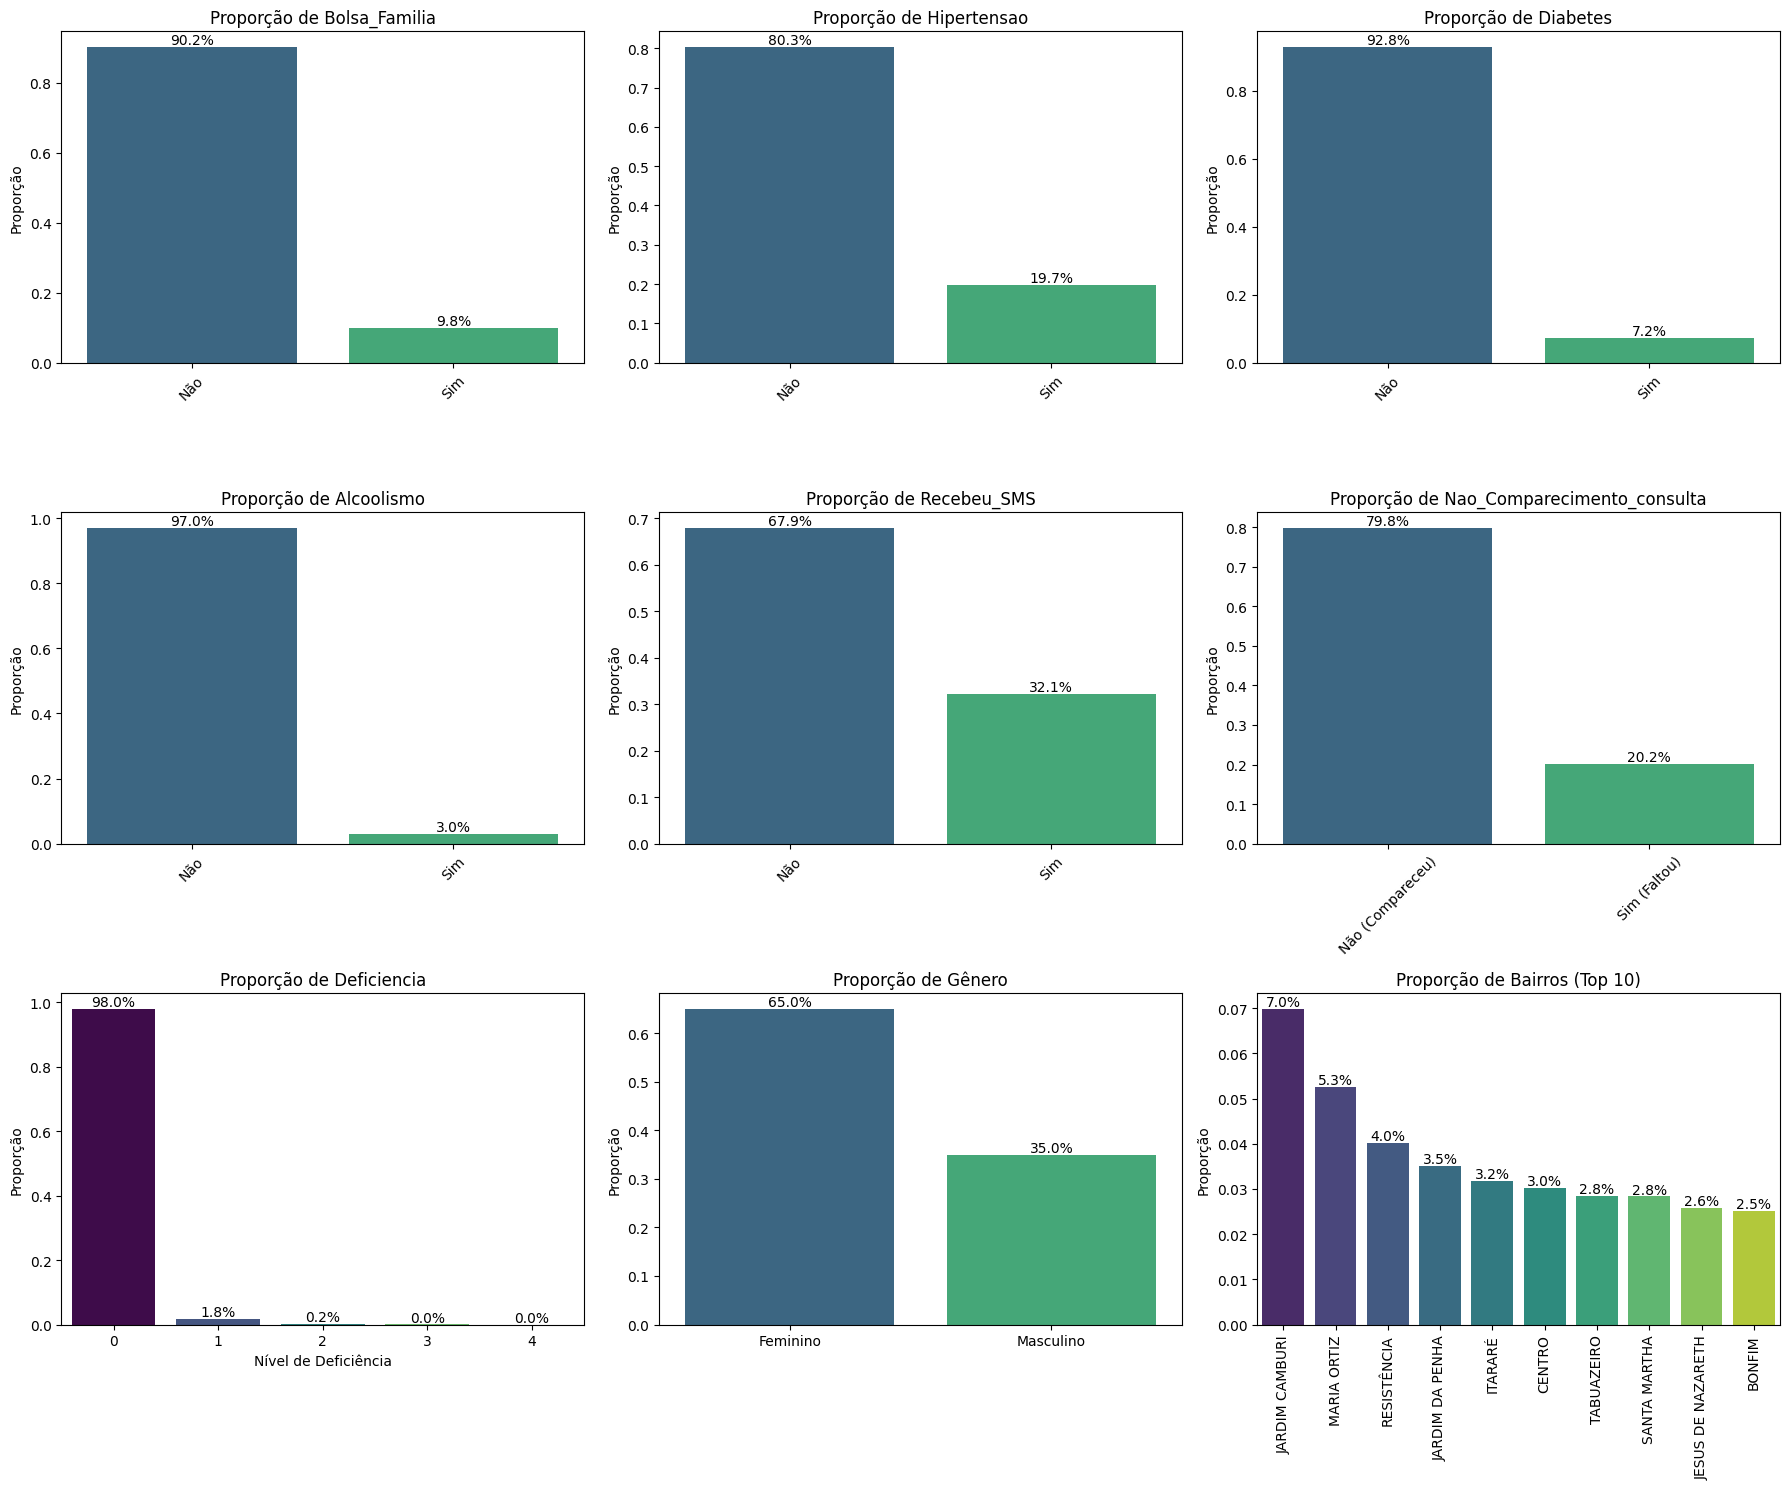

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Variáveis binárias para mapeamento
binarias_0_1 = [
    'Bolsa_Familia',
    'Hipertensao',
    'Diabetes',
    'Alcoolismo',
    'Recebeu_SMS',
    'Nao_Comparecimento_consulta'
]

for i, col in enumerate(binarias_0_1):
    if col == 'Nao_Comparecimento_consulta':
        # Inverte o mapeamento para 'No-show' ter 'Sim' = faltou e 'Não' = compareceu
        data_to_plot = data_nsa[col].map({'Yes': 'Sim (Faltou)', 'No': 'Não (Compareceu)'}).value_counts(normalize=True)
    else:
        data_to_plot = data_nsa[col].map({0: 'Não', 1: 'Sim'}).value_counts(normalize=True)

    sns.barplot(x=data_to_plot.index, y=data_to_plot.values, ax=axes[i], palette='viridis', hue=data_to_plot.index, legend=False)
    axes[i].set_title(f'Proporção de {col}')
    axes[i].set_ylabel('Proporção')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Proporção de Deficiencia (múltiplas categorias)
proporcao_deficiencia = data_nsa['Deficiencia'].value_counts(normalize=True)
sns.barplot(x=proporcao_deficiencia.index, y=proporcao_deficiencia.values, ax=axes[6], palette='viridis', hue=proporcao_deficiencia.index, legend=False)
axes[6].set_title('Proporção de Deficiencia')
axes[6].set_ylabel('Proporção')
axes[6].set_xlabel('Nível de Deficiência')
for p in axes[6].patches:
    axes[6].annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Proporção de Gênero
proporcao_genero = data_nsa['Genero'].map({'F': 'Feminino', 'M': 'Masculino'}).value_counts(normalize=True)
sns.barplot(x=proporcao_genero.index, y=proporcao_genero.values, ax=axes[7], palette='viridis', hue=proporcao_genero.index, legend=False)
axes[7].set_title('Proporção de Gênero')
axes[7].set_ylabel('Proporção')
axes[7].set_xlabel('')
for p in axes[7].patches:
    axes[7].annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Proporção de Bairros (Top 10)
proporcao_bairros = data_nsa['Bairro'].value_counts(normalize=True).head(10)
sns.barplot(x=proporcao_bairros.index, y=proporcao_bairros.values, ax=axes[8], palette='viridis', hue=proporcao_bairros.index, legend=False)
axes[8].set_title('Proporção de Bairros (Top 10)')
axes[8].set_ylabel('Proporção')
axes[8].set_xlabel('')
axes[8].tick_params(axis='x', rotation=90)
for p in axes[8].patches:
    axes[8].annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

#### 3.3 - Proporção de Não-Comparecimento pelas Variáveis Categóricas

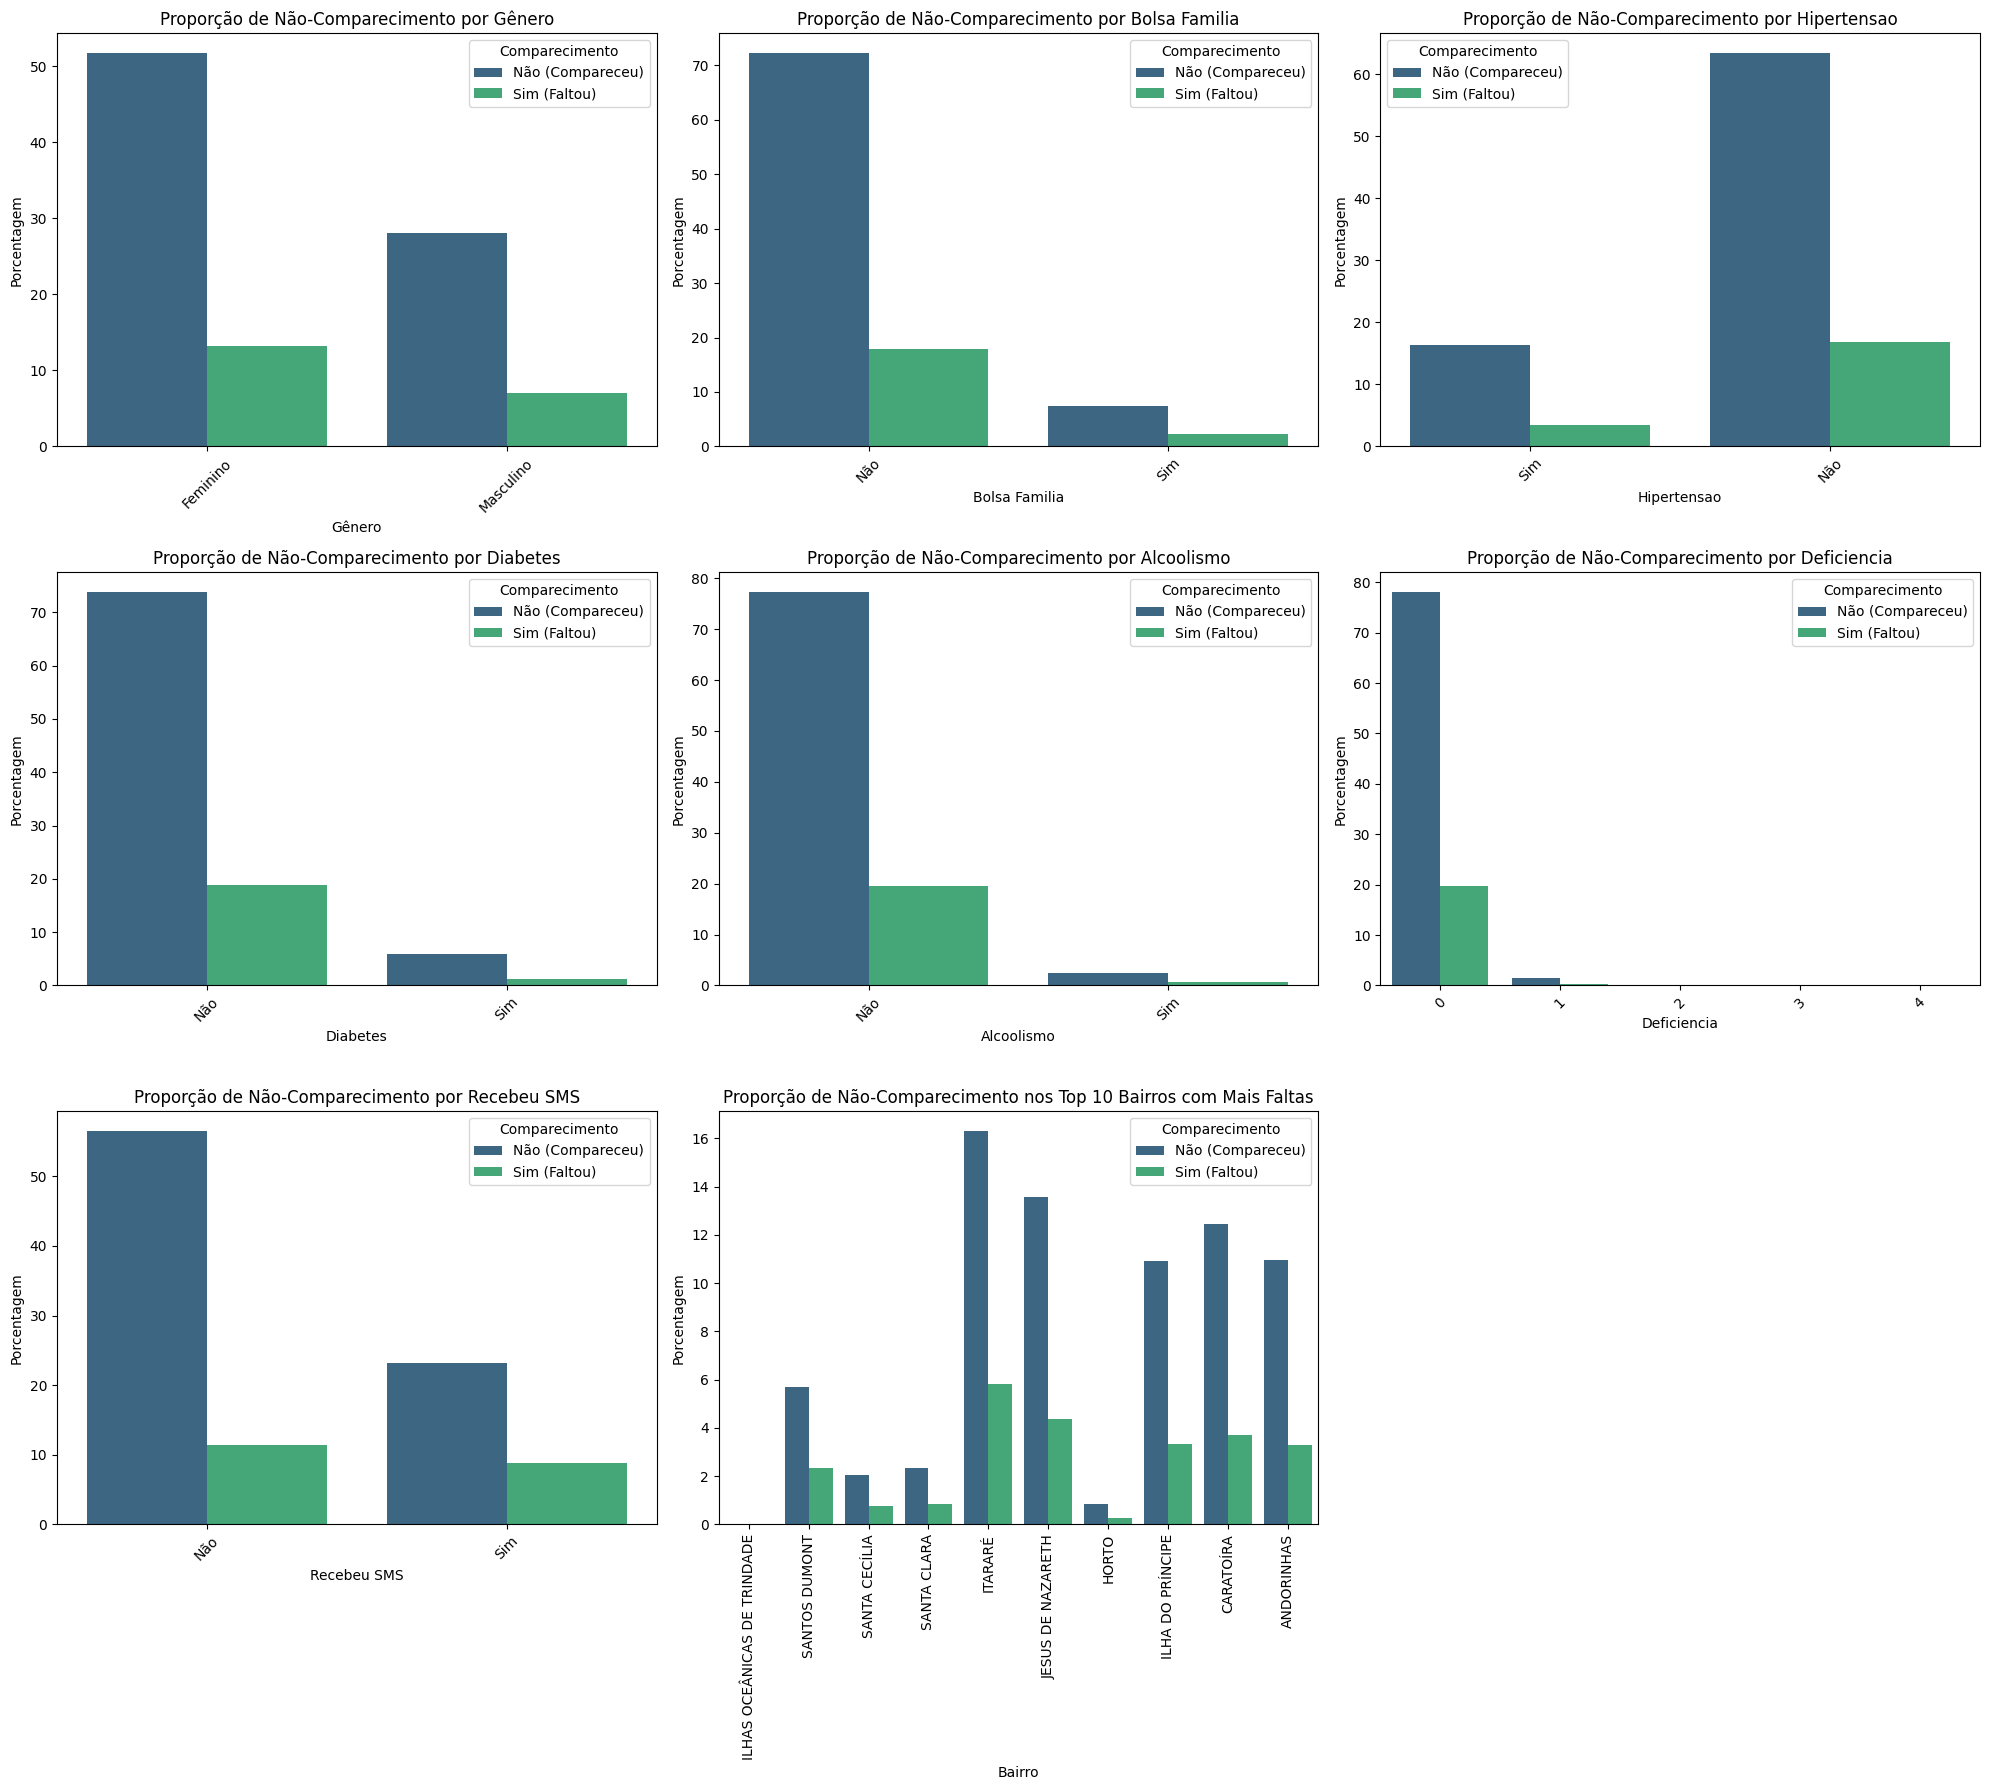

In [11]:

data_nsa['Nao_Comparecimento_consulta_display'] = data_nsa['Nao_Comparecimento_consulta'].map({'Yes': 'Sim (Faltou)', 'No': 'Não (Compareceu)'})

# Define the categorical features to analyze against 'Nao_Comparecimento_consulta'
categorical_features_for_analysis = [
    'Genero',
    'Bolsa_Familia',
    'Hipertensao',
    'Diabetes',
    'Alcoolismo',
    'Deficiencia',
    'Recebeu_SMS'
]

# Set up the subplot grid (3 rows, 3 columns)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 18))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Iterate through features and create countplots
for i, feature in enumerate(categorical_features_for_analysis):
    temp_col_name = f'{feature}_display'
    x_label = feature.replace('_', ' ') # Default label

    # Apply specific mappings for better display on the x-axis
    if feature == 'Genero':
        data_nsa[temp_col_name] = data_nsa[feature].map({'F': 'Feminino', 'M': 'Masculino'})
        x_label = 'Gênero'
    elif feature in ['Bolsa_Familia', 'Hipertensao', 'Diabetes', 'Alcoolismo', 'Recebeu_SMS']:
        data_nsa[temp_col_name] = data_nsa[feature].map({0: 'Não', 1: 'Sim'})
    else: # For 'Deficiencia', use original values as they are already meaningful
        data_nsa[temp_col_name] = data_nsa[feature]

    # Create the countplot showing percentages
    sns.countplot(data=data_nsa, x=temp_col_name, hue='Nao_Comparecimento_consulta_display', ax=axes[i], palette='viridis', stat='percent')
    axes[i].set_title(f'Proporção de Não-Comparecimento por {x_label}')
    axes[i].set_ylabel('Porcentagem')
    axes[i].set_xlabel(x_label)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Comparecimento')

# Handle Bairro separately: find the top 10 bairros with highest 'Sim (Faltou)' rate
bairro_no_show_rates = data_nsa.groupby('Bairro')['Nao_Comparecimento_consulta'].value_counts(normalize=True).unstack().fillna(0)

# Check if 'Yes' column exists in case all values are 'No'
if 'Yes' in bairro_no_show_rates.columns:
    top_10_no_show_bairros = bairro_no_show_rates['Yes'].nlargest(10).index
    # Filter data for top 10 bairros to plot
    data_bairro_filtered = data_nsa[data_nsa['Bairro'].isin(top_10_no_show_bairros)]

    # Plot for Bairro
    sns.countplot(data=data_bairro_filtered, x='Bairro', hue='Nao_Comparecimento_consulta_display', ax=axes[7], palette='viridis', stat='percent', order=top_10_no_show_bairros)
    axes[7].set_title('Proporção de Não-Comparecimento nos Top 10 Bairros com Mais Faltas')
    axes[7].set_ylabel('Porcentagem')
    axes[7].set_xlabel('Bairro')
    axes[7].tick_params(axis='x', rotation=90)
    axes[7].legend(title='Comparecimento')
else:
    # If no 'Yes' column found (meaning no non-attendance), hide this subplot
    axes[7].set_visible(False)

# Hide any remaining unused subplots (if any)
# The loop starts from the index after the last plotted feature (including Bairro if plotted)
start_hide_index = len(categorical_features_for_analysis)
if 'Yes' in bairro_no_show_rates.columns: # If bairro plot was added
    start_hide_index += 1

for j in range(start_hide_index, len(axes)): # Iterate through remaining axes
    axes[j].set_visible(False)

plt.tight_layout() # Adjust layout to prevent overlapping elements
plt.show()

# It's good practice to clean up temporary columns if they are not needed further
for feature in categorical_features_for_analysis:
    temp_col_name = f'{feature}_display'
    if temp_col_name in data_nsa.columns:
        data_nsa.drop(columns=[temp_col_name], inplace=True)
if 'Nao_Comparecimento_consulta_display' in data_nsa.columns:
    data_nsa.drop(columns=['Nao_Comparecimento_consulta_display'], inplace=True)

#### 3.4 - Boxplot da variável idade

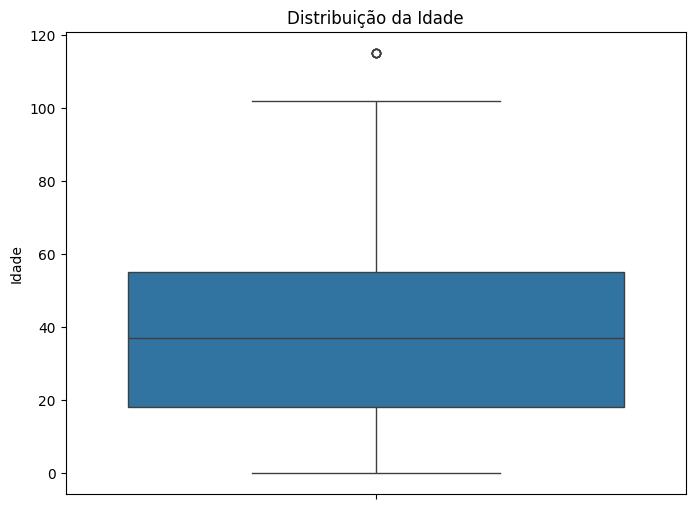

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=data_nsa['Idade'])
plt.title('Distribuição da Idade')
plt.ylabel('Idade')
plt.show()

#### 4 - Feature Engineering

#### 4.1 - Criar variável de diferença de dias entre agendamento e consulta

In [13]:
# Converter as colunas de data para o tipo datetime
data_nsa['Dia_Consulta'] = pd.to_datetime(data_nsa['Dia_Consulta'])
data_nsa['DH_Consulta_Agendada'] = pd.to_datetime(data_nsa['DH_Consulta_Agendada'])

# Calcular a diferença em dias, considerando apenas a parte da data de cada timestamp
data_nsa['Diferenca_Dias_Agendamento'] = (data_nsa['Dia_Consulta'].dt.normalize() - data_nsa['DH_Consulta_Agendada'].dt.normalize()).dt.days

# Exibir as primeiras linhas com a nova coluna
display(data_nsa[['DH_Consulta_Agendada', 'Dia_Consulta', 'Diferenca_Dias_Agendamento']].head())

,DH_Consulta_Agendada,Dia_Consulta,Diferenca_Dias_Agendamento
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,0
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,0
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,0
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,0
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,0


In [14]:
data_nsa['Diferenca_Dias_Agendamento'].describe()

,Diferenca_Dias_Agendamento
count,110526.000000
mean,10.183794
std,15.255034
min,-6.000000
25%,0.000000
50%,4.000000
75%,15.000000
max,179.000000


#### 4.2 - Boxplot da distribuição da variável `Diferenca_Dias_Agendamento` para o dia da consulta.

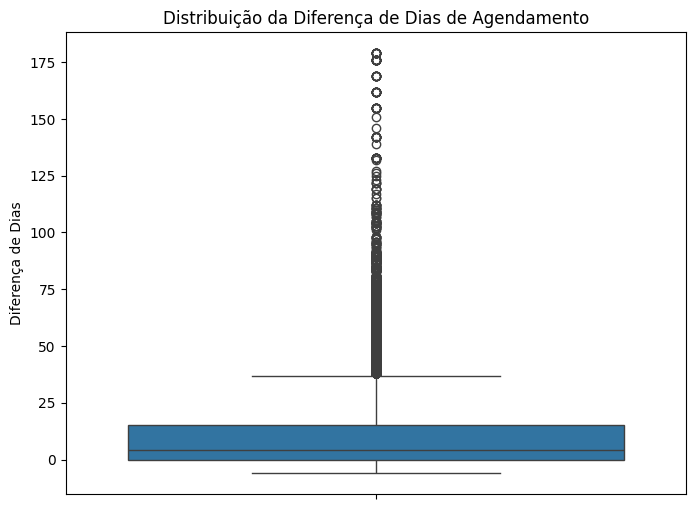

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=data_nsa['Diferenca_Dias_Agendamento'])
plt.title('Distribuição da Diferença de Dias de Agendamento')
plt.ylabel('Diferença de Dias')
plt.show()

#### 4.3 - Criação da feature `Número_Consultas_Atendidas_Anteriores`

Vamos criar uma nova variável que conta o número de consultas **atendidas** por cada paciente. Ou seja se um paciente da bd já esteve em uma consulta a variável vai contabilizar a qtd.

In [16]:
# 1. Ordenar o DataFrame por ID_Paciente e Dia_Consulta para garantir a ordem cronológica
data_nsa.sort_values(by=['ID_Paciente', 'Dia_Consulta'], inplace=True)

# 2. Criar um indicador numérico para 'Nao_Comparecimento_consulta' (1 se 'Sim' (faltou), 0 se 'Não' (compareceu))
data_nsa['faltou_num'] = data_nsa['Nao_Comparecimento_consulta'].map({'Yes': 1, 'No': 0})

# 3. Calcular o número de consultas anteriores para cada paciente
# cumcount() retorna uma contagem baseada em 0 dentro de cada grupo, que representa o número de consultas *anteriores*
data_nsa['n_consultas_anteriores'] = data_nsa.groupby('ID_Paciente').cumcount()

# 4. Calcular o número de faltas anteriores para cada paciente
# Usamos cumsum() e shift(1) para obter a soma de 'faltou_num' das linhas *anteriores* dentro do grupo.
# fillna(0) lida com a primeira consulta, onde shift(1) produziria NaN.
data_nsa['n_faltas_anteriores'] = data_nsa.groupby('ID_Paciente')['faltou_num'].transform(lambda x: x.cumsum().shift(1).fillna(0)).astype(int)

# 5. Calcular a taxa histórica de falta
# Lidar com divisão por zero (para pacientes novos) preenchendo NaNs com 0.
data_nsa['taxa_falta_historica'] = (data_nsa['n_faltas_anteriores'] / data_nsa['n_consultas_anteriores']).fillna(0)
# Substituir possíveis valores infinitos (se n_consultas_anteriores for 0 e n_faltas_anteriores não) por NaN e depois por 0
data_nsa['taxa_falta_historica'] = data_nsa['taxa_falta_historica'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 6. Criar uma flag para pacientes novos (1 se for a primeira consulta no dataset, 0 caso contrário)
data_nsa['paciente_novo'] = (data_nsa['n_consultas_anteriores'] == 0).astype(int)

# Exibir as novas features para uma amostra de pacientes para verificação
display(data_nsa[['ID_Paciente', 'Dia_Consulta', 'Nao_Comparecimento_consulta',
                  'n_consultas_anteriores', 'n_faltas_anteriores',
                  'taxa_falta_historica', 'paciente_novo']].head(10))

# Remover a coluna temporária 'faltou_num' se não for mais necessária
data_nsa.drop(columns=['faltou_num'], inplace=True)

,ID_Paciente,Dia_Consulta,Nao_Comparecimento_consulta,n_consultas_anteriores,n_faltas_anteriores,taxa_falta_historica,paciente_novo
100517,3.921784e+04,2016-06-03 00:00:00+00:00,No,0,0,0.0,1
105430,4.374176e+04,2016-06-01 00:00:00+00:00,No,0,0,0.0,1
3950,9.377953e+04,2016-05-18 00:00:00+00:00,No,0,0,0.0,1
73303,1.417242e+05,2016-05-02 00:00:00+00:00,No,0,0,0.0,1
73228,5.376153e+05,2016-05-06 00:00:00+00:00,No,0,0,0.0,1
54611,5.628261e+06,2016-05-13 00:00:00+00:00,Yes,0,0,0.0,1
40692,1.183186e+07,2016-05-19 00:00:00+00:00,No,0,0,0.0,1
58616,2.263866e+07,2016-05-03 00:00:00+00:00,No,0,0,0.0,1
88585,2.263866e+07,2016-06-08 00:00:00+00:00,No,1,0,0.0,0
83628,5.216894e+07,2016-05-16 00:00:00+00:00,No,0,0,0.0,1


#### 5 - Análise Estatítica - Teste Qui-Quadrado e Teste-T Student

### 5.1 - Análise de Relacionamento entre Variáveis Categóricas e a Target (Teste Qui-Quadrado)

O teste Qui-Quadrado (`Chi-squared test`) é usado para determinar se existe uma associação significativa entre duas variáveis categóricas. Neste caso, vamos aplicá-lo a cada uma das nossas variáveis categóricas em relação à variável `Nao_Comparecimento_consulta` para verificar se elas possuem alguma dependência estatística.

In [17]:
from scipy.stats import chi2_contingency

# Lista de variáveis categóricas para testar
# Usamos as features categóricas definidas anteriormente no pipeline
# Excluímos 'Bairro' e 'Deficiencia' inicialmente pois podem ter muitas categorias
# e vamos focar nas binárias ou de menor cardinalidade primeiro
categorical_features_for_chi2 = [
    'Genero',
    'Bolsa_Familia',
    'Hipertensao',
    'Diabetes',
    'Alcoolismo',
    'Recebeu_SMS',
    'Deficiencia',
    'paciente_novo'
]

target_variable = 'Nao_Comparecimento_consulta'

print("### Teste Qui-Quadrado para Variáveis Categóricas ###\n")

for feature in categorical_features_for_chi2:
    print(f"Analisando a relação entre '{feature}' e '{target_variable}':")
    # Cria uma tabela de contingência
    contingency_table = pd.crosstab(data_nsa[feature], data_nsa[target_variable])

    # Realiza o teste Qui-Quadrado
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"  Estatística Qui-Quadrado: {chi2:.4f}")
    print(f"  P-valor: {p_value:.4f}")

    # Interpretação do p-valor
    alpha = 0.05
    if p_value < alpha:
        print(f"  Conclusão: Rejeitamos a hipótese nula. Há uma relação estatisticamente significativa entre '{feature}' e '{target_variable}'.")
    else:
        print(f"  Conclusão: Não rejeitamos a hipótese nula. Não há evidência de uma relação estatisticamente significativa entre '{feature}' e '{target_variable}'.")
    print("\n" + "-"*50 + "\n")

print("### Teste Qui-Quadrado para Bairro ###\n")
# Para Bairro, vamos analisar apenas os top N bairros para evitar tabelas muito grandes e resultados menos úteis
# Vamos pegar os 10 bairros mais frequentes para simplificar
top_n_bairros = data_nsa['Bairro'].value_counts().nlargest(10).index
data_bairros_filtered = data_nsa[data_nsa['Bairro'].isin(top_n_bairros)]

contingency_table_bairro = pd.crosstab(data_bairros_filtered['Bairro'], data_bairros_filtered[target_variable])
chi2_bairro, p_value_bairro, dof_bairro, expected_bairro = chi2_contingency(contingency_table_bairro)

print(f"Analisando a relação entre 'Bairro (Top {len(top_n_bairros)})' e '{target_variable}':")
print(f"  Estatística Qui-Quadrado: {chi2_bairro:.4f}")
print(f"  P-valor: {p_value_bairro:.4f}")
if p_value_bairro < alpha:
    print(f"  Conclusão: Rejeitamos a hipótese nula. Há uma relação estatisticamente significativa entre 'Bairro' e '{target_variable}'.")
else:
    print(f"  Conclusão: Não rejeitamos a hipótese nula. Não há evidência de uma relação estatisticamente significativa entre 'Bairro' e '{target_variable}'.")
print("\n" + "-"*50 + "\n")

### Teste Qui-Quadrado para Variáveis Categóricas ###

Analisando a relação entre 'Genero' e 'Nao_Comparecimento_consulta':
  Estatística Qui-Quadrado: 1.8565
  P-valor: 0.1730
  Conclusão: Não rejeitamos a hipótese nula. Não há evidência de uma relação estatisticamente significativa entre 'Genero' e 'Nao_Comparecimento_consulta'.

--------------------------------------------------

Analisando a relação entre 'Bolsa_Familia' e 'Nao_Comparecimento_consulta':
  Estatística Qui-Quadrado: 93.5670
  P-valor: 0.0000
  Conclusão: Rejeitamos a hipótese nula. Há uma relação estatisticamente significativa entre 'Bolsa_Familia' e 'Nao_Comparecimento_consulta'.

--------------------------------------------------

Analisando a relação entre 'Hipertensao' e 'Nao_Comparecimento_consulta':
  Estatística Qui-Quadrado: 140.6686
  P-valor: 0.0000
  Conclusão: Rejeitamos a hipótese nula. Há uma relação estatisticamente significativa entre 'Hipertensao' e 'Nao_Comparecimento_consulta'.

-------------------

### 5.2 - Análise de Relacionamento entre Variável Contínua (Idade) e a Target (Teste t de Student)

O teste t de Student para amostras independentes é utilizado para comparar as médias de uma variável contínua entre dois grupos distintos. Neste caso, vamos comparar a média da `Idade` entre os pacientes que `Não` compareceram e os que `Sim` faltaram à consulta (`Nao_Comparecimento_consulta`).

In [18]:
from scipy.stats import ttest_ind

# Separar a idade dos pacientes que compareceram e dos que faltaram
idade_compareceu = data_nsa[data_nsa['Nao_Comparecimento_consulta'] == 'No']['Idade']
idade_faltou = data_nsa[data_nsa['Nao_Comparecimento_consulta'] == 'Yes']['Idade']

# Realizar o teste t de Student para amostras independentes
t_statistic, p_value = ttest_ind(idade_compareceu, idade_faltou, equal_var=False) # equal_var=False assume variâncias desiguais

print("### Teste t de Student para Idade vs. Nao_Comparecimento_consulta ###\n")
print(f"Média de Idade (Compareceu): {idade_compareceu.mean():.2f}")
print(f"Média de Idade (Faltou): {idade_faltou.mean():.2f}")
print(f"Estatística t: {t_statistic:.4f}")
print(f"P-valor: {p_value:.4f}")

# Interpretação do p-valor
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusão: Rejeitamos a hipótese nula. Há uma diferença estatisticamente significativa na média de idade entre quem compareceu e quem faltou (p-valor < {alpha}).")
else:
    print(f"\nConclusão: Não rejeitamos a hipótese nula. Não há evidência de uma diferença estatisticamente significativa na média de idade entre quem compareceu e quem faltou (p-valor >= {alpha}).")


### Teste t de Student para Idade vs. Nao_Comparecimento_consulta ###

Média de Idade (Compareceu): 37.79
Média de Idade (Faltou): 34.32
Estatística t: 20.8311
P-valor: 0.0000

Conclusão: Rejeitamos a hipótese nula. Há uma diferença estatisticamente significativa na média de idade entre quem compareceu e quem faltou (p-valor < 0.05).


#### 5.3 - A partir dos testes anteriores, para a Regressão Log. vamos optar por retirar variáveis que não possuem significancia estatística com a nossa variável target (Não_Comparecimento_consulta), são elas: Genero; Alcoolismo; Deficiencia.

#### 6 - Treinamento e Seleção de Modelos

#### 6.1 - Regressão Logística

Treinando o modelo de Regressão Logística...
Treinamento concluído!

Métricas de Avaliação do Modelo de Regressão Logística:
Acurácia: 0.6604
Precisão: 0.3184
Recall: 0.5977
F1-Score: 0.4154
AUC ROC: 0.6862


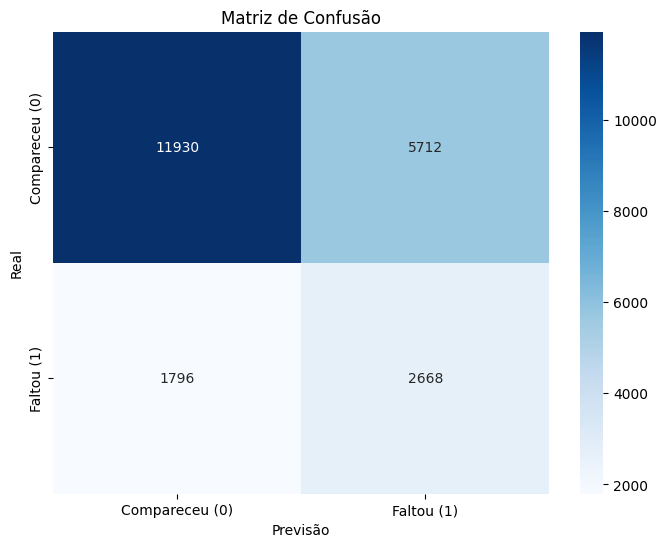

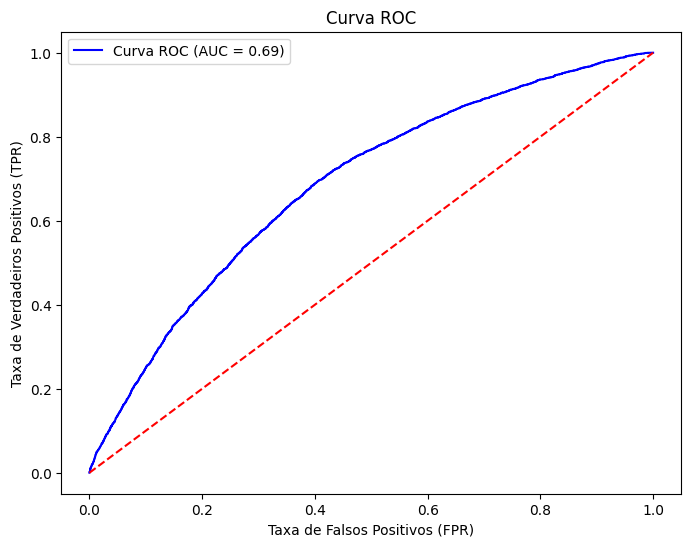

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir a variável target (y) e as features (X)
# Converter 'Nao_Comparecimento_consulta' para binário: 0 para 'No' (compareceu), 1 para 'Yes' (faltou)
data_nsa['target'] = data_nsa['Nao_Comparecimento_consulta'].map({'No': 0, 'Yes': 1})
y = data_nsa['target']

# Features a serem utilizadas (excluindo IDs, datas originais, e a target original/temporárias)
# As novas features criadas serão incluídas automaticamente se estiverem no DataFrame
features = [
    'Idade', 'Bairro', 'Bolsa_Familia', 'Hipertensao', 'Diabetes',
   'Recebeu_SMS', 'Diferenca_Dias_Agendamento',
    'n_consultas_anteriores', 'n_faltas_anteriores', 'taxa_falta_historica', 'paciente_novo'
]
X = data_nsa[features]

# Identificar colunas numéricas e categóricas
# REDEFINIR explicitamente as listas para evitar mutação por outras células
numerical_features = [
    'Idade', 'Diferenca_Dias_Agendamento', 'n_consultas_anteriores',
    'n_faltas_anteriores', 'taxa_falta_historica',
    'Bolsa_Familia', 'Hipertensao',
    'Diabetes', 'Recebeu_SMS'
]

categorical_features = [ 'Bairro', 'paciente_novo']

# 2. Pré-processamento com ColumnTransformer
# Numericas: Scaler
# Categoricas: One-Hot Encoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # Usar as listas redefinidas
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # Usar as listas redefinidas
    ])

# 3. Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Criar o Pipeline: pré-processamento + modelo de Regressão Logística
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')) # 'balanced' para lidar com desbalanceamento
])

# 5. Treinar o modelo
print("Treinando o modelo de Regressão Logística...")
model_pipeline.fit(X_train, y_train)
print("Treinamento concluído!")

# 6. Fazer previsões no conjunto de teste
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1] # Probabilidade da classe positiva (faltou)

# 7. Avaliar o modelo
print("\nMétricas de Avaliação do Modelo de Regressão Logística:")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Visualizar a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Compareceu (0)', 'Faltou (1)'],
            yticklabels=['Compareceu (0)', 'Faltou (1)'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

# Visualizar a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

#### 6.1.1 - Análise das Métricas do Modelo:

Acurácia (0.6604): Acurácia é a proporção de previsões corretas (tanto 'compareceu' quanto 'faltou') sobre o total de casos. Uma acurácia de 66.04% significa que o modelo acerta a classificação em cerca de dois terços das vezes. No entanto, para problemas com classes desbalanceadas (como 'faltou' vs. 'compareceu'), a acurácia pode ser enganosa. Se a maioria dos pacientes comparece, um modelo que sempre prevê 'compareceu' já teria uma alta acurácia.

Precisão (0.3184): A Precisão nos diz, de todos os pacientes que o modelo previu que faltariam, quantos realmente faltaram. Uma precisão de 31.84% significa que apenas cerca de um terço dos pacientes que seu modelo sinaliza como 'prováveis faltantes' de fato faltam. Os outros dois terços são 'falsos positivos' – pacientes que o modelo previu que faltariam, mas que na verdade compareceram.

Impacto no seu objetivo: Uma precisão baixa significa que, se você usar o modelo para acionar intervenções (como ligar para o paciente, etc.), você estará gastando recursos com muitos pacientes que iriam comparecer de qualquer forma. Isso não ajuda a evitar gastos à toa para os médicos, pois muitas das intervenções serão desnecessárias.
Recall (0.5977): O Recall nos informa, de todos os pacientes que realmente faltaram, quantos o modelo conseguiu identificar corretamente. Um Recall de 59.77% significa que o modelo está identificando quase 60% dos pacientes que faltarão. Cerca de 40% dos que realmente faltarão ainda são 'perdidos' pelo modelo (falsos negativos).

Impacto no seu objetivo: Um Recall mais alto é desejável para identificar o máximo possível de faltantes. Os 40% que o modelo não identificou ainda representam custos de tempo perdido para o médico, já que não houve intervenção para esses casos.
F1-Score (0.4154): O F1-Score é uma média harmônica entre Precisão e Recall. Ele é útil quando você busca um equilíbrio entre identificar bem os positivos (Recall) e ter poucas previsões erradas (Precisão). Seu F1-Score de 0.4160 indica um equilíbrio moderado, mas tanto a Precisão quanto o Recall têm espaço para melhorias.

AUC ROC (0.6862): A Área sob a Curva ROC mede a capacidade do seu modelo de distinguir entre as classes. Um valor de 0.5 é aleatório, e 1.0 é perfeito. Um AUC ROC de 0.6862 mostra que seu modelo é melhor que o acaso em distinguir quem falta de quem não falta, mas ainda tem uma capacidade de discriminação moderada.

Conclusão e Próximos Passos para seu Objetivo:

Com base no meu objetivo de evitar gastos desnecessários para médicos de plantão, você precisa de um modelo que:

Tenha um Recall razoavelmente alto: para identificar a maioria dos pacientes que faltarão.
Tenha uma Precisão mais alta: para garantir que as intervenções (ligações, remarcações) sejam direcionadas principalmente a quem realmente faltaria, minimizando o desperdício de recursos com quem compareceria.
O seu modelo atual tem um Recall aceitável (quase 60%), mas a Precisão está baixa (31.91%). Isso significa que, embora ele encontre muitos dos faltantes, ele também sinaliza muitos pacientes que não faltariam. Se o custo de uma intervenção desnecessária (falso positivo) for alto, essa baixa precisão pode ser um problema.

#### 6.2 - Random Forest

Manteremos o mesmo pré-processamento e a mesma divisão de dados para uma comparação justa.

Treinando o modelo Random Forest...
Treinamento do Random Forest concluído!

Métricas de Avaliação do Modelo Random Forest:
Acurácia: 0.7666
Precisão: 0.3683
Recall: 0.2177
F1-Score: 0.2737
AUC ROC: 0.6890


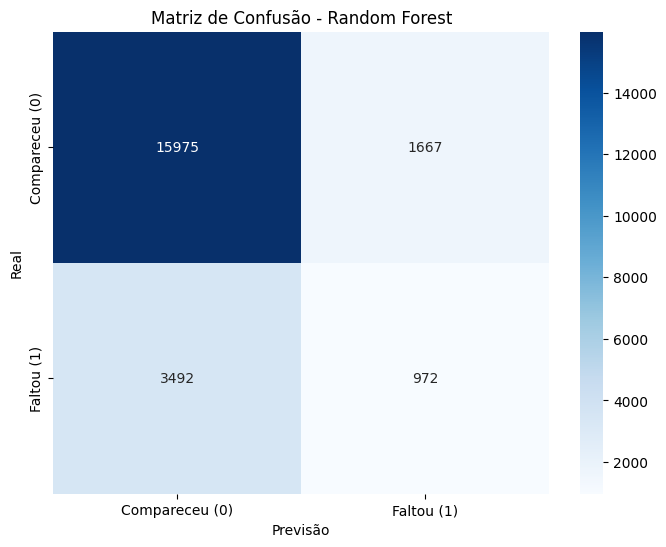

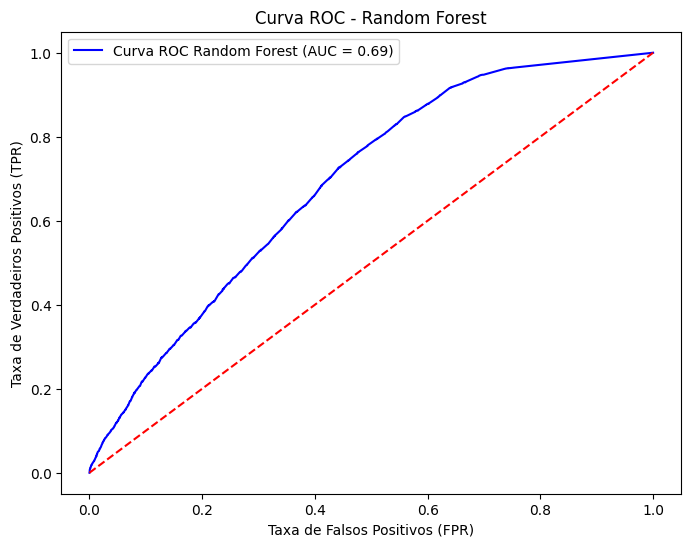

In [24]:
from sklearn.ensemble import RandomForestClassifier

# 1. Criar o Pipeline: pré-processamento (já definido) + modelo Random Forest
# Usaremos class_weight='balanced' para lidar com o desbalanceamento de classes
# O número de estimadores (n_estimators) e a profundidade máxima (max_depth) são parâmetros importantes para ajustar.
# Vamos começar com valores padrão e podemos otimizá-los posteriormente.
model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 2. Treinar o modelo Random Forest
print("Treinando o modelo Random Forest...")
model_pipeline_rf.fit(X_train, y_train)
print("Treinamento do Random Forest concluído!")

# 3. Fazer previsões no conjunto de teste
y_pred_rf = model_pipeline_rf.predict(X_test)
y_pred_proba_rf = model_pipeline_rf.predict_proba(X_test)[:, 1] # Probabilidade da classe positiva (faltou)

# 4. Avaliar o modelo Random Forest
print("\nMétricas de Avaliação do Modelo Random Forest:")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC ROC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

# Visualizar a Matriz de Confusão para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Compareceu (0)', 'Faltou (1)'],
            yticklabels=['Compareceu (0)', 'Faltou (1)'])
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

# Visualizar a Curva ROC para Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', label=f'Curva ROC Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Random Forest')
plt.legend()
plt.show()

#### 6.2.1 - Embora o Random Forest tenha melhorado a precisão, ele o fez ao custo de uma redução drástica no Recall. Para o meu objetivo de evitar gastos desnecessários para médicos, precisamos de um equilíbrio, onde a Precisão seja alta, mas o Recall não seja excessivamente baixo. Perder a identificação de quase 80% das faltas pode ainda resultar em custos significativos para os médicos.

#### 6.3 - Treinamento e Avaliação do Modelo XGBoost

Agora vamos explorar o XGBoost (Extreme Gradient Boosting), que é um algoritmo de *ensemble* baseado em árvores de decisão. Ele é altamente eficiente e costuma entregar um desempenho robusto em uma variedade de problemas, incluindo classificação. Manteremos o mesmo pré-processamento e divisão de dados para que a comparação seja consistente.

Treinando o modelo XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:24:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Treinamento do XGBoost concluído!

Métricas de Avaliação do Modelo XGBoost:
Acurácia: 0.6167
Precisão: 0.3162
Recall: 0.7728
F1-Score: 0.4488
AUC ROC: 0.7391


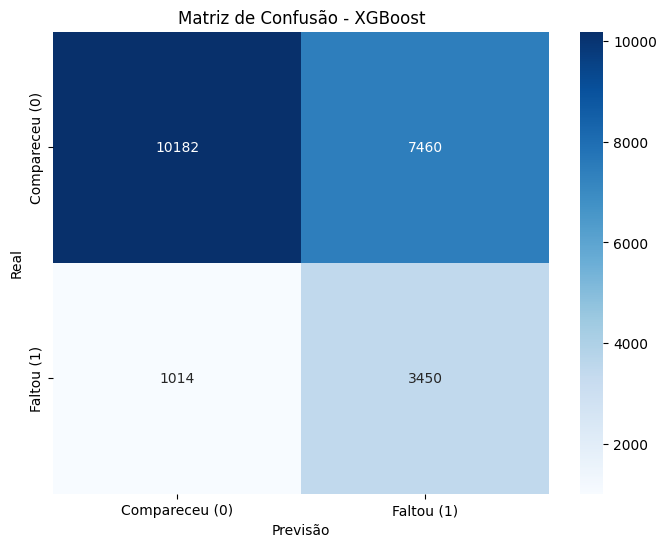

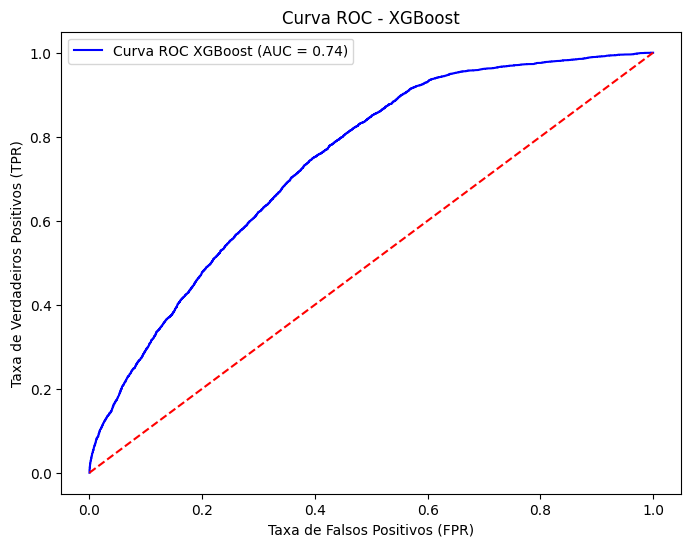

In [26]:
from xgboost import XGBClassifier

# 1. Criar o Pipeline: pré-processamento (já definido) + modelo XGBoost
# Usaremos scale_pos_weight para lidar com o desbalanceamento de classes,
# que é a abordagem recomendada pelo XGBoost para isso.
# A proporção é (número de instâncias negativas / número de instâncias positivas).

# Calcular a proporção para scale_pos_weight
neg_count = y_train.value_counts()[0] # Contagem da classe majoritária (No)
pos_count = y_train.value_counts()[1] # Contagem da classe minoritária (Yes)
scale_pos_weight_value = neg_count / pos_count

model_pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42,
        use_label_encoder=False, # Definir como False para suprimir o warning
        eval_metric='logloss',   # Definir uma métrica de avaliação para suprimir o warning
        scale_pos_weight=scale_pos_weight_value
    ))
])

# 2. Treinar o modelo XGBoost
print("Treinando o modelo XGBoost...")
model_pipeline_xgb.fit(X_train, y_train)
print("Treinamento do XGBoost concluído!")

# 3. Fazer previsões no conjunto de teste
y_pred_xgb = model_pipeline_xgb.predict(X_test)
y_pred_proba_xgb = model_pipeline_xgb.predict_proba(X_test)[:, 1] # Probabilidade da classe positiva (faltou)

# 4. Avaliar o modelo XGBoost
print("\nMétricas de Avaliação do Modelo XGBoost:")
print(f"Acurácia: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"AUC ROC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

# Visualizar a Matriz de Confusão para XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Compareceu (0)', 'Faltou (1)'],
            yticklabels=['Compareceu (0)', 'Faltou (1)'])
plt.title('Matriz de Confusão - XGBoost')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

# Visualizar a Curva ROC para XGBoost
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='blue', label=f'Curva ROC XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba_xgb):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - XGBoost')
plt.legend()
plt.show()

#### 6.3.1 - Recall: O XGBoost apresenta o maior Recall (0.7728) entre todos os modelos, o que significa que ele é o melhor em identificar os pacientes que realmente faltarão. Isso é um ponto muito forte para o objetivo de não perder pacientes que necessitam de intervenção.


#### 6.3.2 - Análise da Importância das Variáveis para o XGBoost

Entender a importância das features é crucial para interpretar o modelo e potencialmente refinar a seleção de variáveis. O XGBoost, sendo um modelo baseado em árvores, pode fornecer a importância de cada feature, indicando o quanto cada uma contribui para a redução da impureza (ou erro) nas árvores do modelo.

### Importância das Variáveis (XGBoost) ###


,Feature,Importance
1,num__Diferenca_Dias_Agendamento,0.074087
3,num__n_faltas_anteriores,0.039189
79,cat__Bairro_SANTOS DUMONT,0.032351
4,num__taxa_falta_historica,0.028288
36,cat__Bairro_GURIGICA,0.024585
...,...,...
9,cat__Bairro_AEROPORTO,0.000000
43,cat__Bairro_ILHAS OCEÂNICAS DE TRINDADE,0.000000
60,cat__Bairro_PARQUE INDUSTRIAL,0.000000
90,cat__paciente_novo_0,0.000000


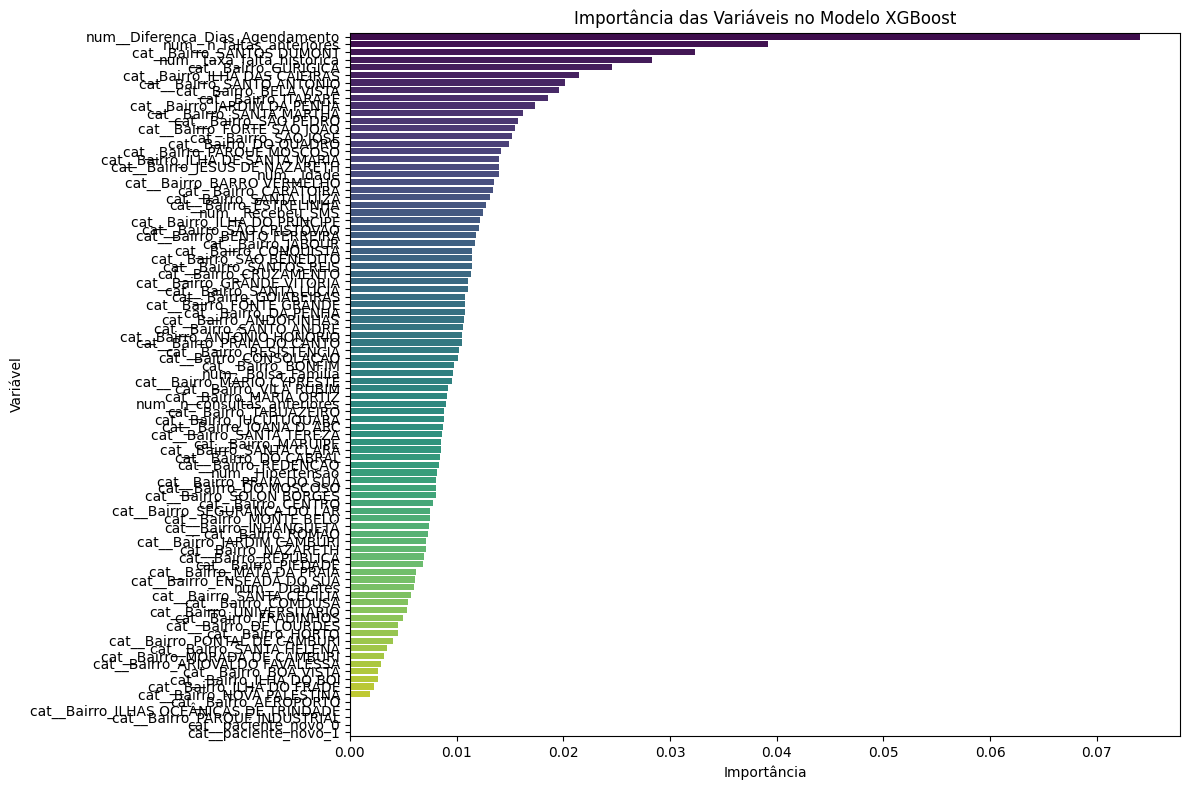

In [28]:
import matplotlib.pyplot as plt

# Obter o classificador XGBoost do pipeline
xgb_classifier = model_pipeline_xgb.named_steps['classifier']

# Obter os nomes das features após o pré-processamento
# É necessário acessar o preprocessor e então obter os nomes das features transformadas
feature_names_out = model_pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()

# Criar um DataFrame com a importância das features
feature_importances = pd.DataFrame({
    'Feature': feature_names_out,
    'Importance': xgb_classifier.feature_importances_
})

# Ordenar as features por importância
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print("### Importância das Variáveis (XGBoost) ###")
display(feature_importances)

# Visualizar a importância das features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis', hue='Feature', legend=False)
plt.title('Importância das Variáveis no Modelo XGBoost')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

#### 7 - Conclusão Final do Modelo XGBoost e Próximos Passos

Aprofundando a análise do modelo XGBoost, tanto nas métricas de desempenho quanto na importância das variáveis, chegamos a uma compreensão mais completa de seu potencial para prever o não comparecimento a consultas médicas.

**Desempenho do Modelo:**

O XGBoost demonstrou um **Recall** consistentemente alto (0.7728), sendo o melhor modelo em identificar pacientes que *realmente faltarão*. Para o objetivo de evitar o desperdício de tempo e recursos dos médicos, é crucial minimizar os falsos negativos (pacientes que faltam, mas o modelo previu que compareceriam). Um Recall alto significa que estamos "pegando" a maioria dos faltantes.

Além disso, o **AUC ROC** do XGBoost (0.7391) é o mais alto entre os modelos testados, indicando uma excelente capacidade de distinção entre as classes de 'compareceu' e 'faltou'. Embora a **Precisão** (0.3162) ainda seja um desafio, o forte Recall e AUC ROC posicionam o XGBoost como o modelo mais promissor para este problema.

**Variáveis Mais Importantes:**

A análise de importância das features reforça os fatores-chave que influenciam o não comparecimento:

1.  **`num__Diferenca_Dias_Agendamento`**: A principal variável, indicando que o tempo entre o agendamento e a consulta tem um grande impacto. Agendamentos com muita antecedência ou muito em cima da hora podem ter diferentes probabilidades de falta.
2.  **`num__n_faltas_anteriores`**: O histórico de faltas do paciente é um forte preditor, mostrando que padrões de comportamento passados são cruciais.
3.  **`cat__Bairro_SANTOS DUMONT` / `cat__Bairro_GURIGICA` (e outros bairros)**: A localização do paciente é relevante, possivelmente refletindo acessibilidade, condições socioeconômicas ou outras características locais.
4.  **`num__taxa_falta_historica`**: Corrobora a importância do histórico do paciente, oferecendo uma métrica relativa do comportamento de falta.
5.  **`num__Idade`**: A idade também desempenha um papel, sugerindo que diferentes faixas etárias têm diferentes taxas de comparecimento.

**Próximos Passos e Recomendações:**

1.  **Engenharia de Features Focada:** Com base nas features mais importantes, explorar novas formas de capturar essa informação. Por exemplo, categorizar `Diferenca_Dias_Agendamento` em intervalos significativos, ou investigar mais a fundo os bairros com maior taxa de não comparecimento.
2.  **Validação Cruzada (Cross-validation):** Para garantir a robustez do modelo, é fundamental avaliar seu desempenho usando validação cruzada para ter uma estimativa mais confiável de como ele se comportará em dados não vistos.
3.  **Análise de Custo-Benefício:** Trabalhar em conjunto com especialistas da área médica para quantificar o custo de um falso positivo (intervenção desnecessária) e o custo de um falso negativo (falta não prevenida). Essa análise pode guiar a escolha *ideal* do limiar que minimiza os custos totais para a clínica.

O modelo XGBoost, com seu forte Recall e a compreensão das variáveis mais importantes, oferece uma base sólida para a implementação de um sistema preditivo que pode efetivamente auxiliar os médicos a reduzir o desperdício de tempo e recursos causados por não comparecimentos.